# Modelo Predictivo para Estimación de Precios – Airbnb Buenos Aires (2025)

El objetivo es desarrollar un **modelo predictivo de regresión** para estimar el precio de alojamientos de Airbnb en la Ciudad Autónoma de Buenos Aires, utilizando información proveniente del dataset de **Inside Airbnb (enero 2025)**.

A diferencia del notebook exploratorio, esta notebook se centra exclusivamente en:

- Entrenar y evaluar **modelos de regresión**,  
- Comparar métricas de desempeño,  
- Interpretar la importancia de las variables que explican el precio,  
- Extraer conclusiones técnicas y de negocio,  
- Reflexionar sobre cómo este modelo podría escalar a un entorno real.

## Contenidos del notebook

1. **Carga del dataset final**
2. **Preparación de variables predictoras (X) y variable objetivo (y)**  
3. **Train–test split**  
4. **Modelos baseline**  
   - Regresión Lineal  
   - Random Forest Regressor  
5. **Métricas de evaluación**  
   - RMSE  
   - MAE  
   - R²  
6. **Interpretación de resultados**  
   - Coeficientes / Importancia de features  
7. **Conclusiones técnicas**  
8. **Reflexión sobre despliegue / producción del modelo**  
9. **Cierre del análisis**

---

### Nota para el lector
Este notebook está diseñado para ser claro, conciso y orientado a la toma de decisiones.  
Los detalles exhaustivos del EDA, la limpieza completa y la documentación previa se encuentran en el repositorio, pero aquí solo se incluye aquello estrictamente necesario para entrenar y evaluar el modelo.

Link a la notebook de EDA (limpieza, analisis exploratorio y preprocesamiento resultante en el dataset utilizado aca): https://colab.research.google.com/drive/1X9BwxKRvRY4vfZk5dzskBU1KlrNh432Y?usp=sharing


In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import gdown
import seaborn as sns
from scipy.stats import skew
import time
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from datetime import datetime
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from google.colab import drive
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

In [62]:
drive.mount('/content/drive', force_remount=True)
df = pd.read_csv('/content/drive/MyDrive/TP Analitica Descriptiva/Datasets/df_machine_learning.csv')

Mounted at /content/drive


In [63]:
semilla = 142857

### Definición de variables predictoras (X) y variable objetivo (y)

Para el modelado predictivo necesitamos separar el dataset en:

- **X**: todas las variables independientes (features) que utilizaremos para estimar el precio.
- **y**: la variable objetivo, que en este caso es el **precio** del alojamiento.

En esta etapa ya contamos con un dataset procesado, sin los outliers detectados previamente y con las transformaciones necesarias aplicadas.  
Por lo tanto, simplemente removemos la columna `price` de X y la conservamos como `y`.

A continuación realizamos la división del dataset en conjuntos de entrenamiento y prueba. Esto es fundamental para evaluar la capacidad de generalización del modelo en datos que no vio durante el entrenamiento.


In [64]:
# X será todo menos la columna 'Status' (la target)
X = df.drop(columns=['price'])

# y será la columna 'Status' (la target)
y = df['price']

# Realizamos el split 70/30
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=semilla)

# Verificamos el tamaño de los datos
print(f"Tamaño de X_train: {X_train.shape}")
print(f"Tamaño de X_test: {X_test.shape}")
print(f"Tamaño de y_train: {y_train.shape}")
print(f"Tamaño de y_test: {y_test.shape}")

Tamaño de X_train: (23384, 44)
Tamaño de X_test: (10023, 44)
Tamaño de y_train: (23384,)
Tamaño de y_test: (10023,)


Como se observa, el split 70/30 generó dos subconjuntos bien proporcionados:

- **X_train** y **y_train**: utilizados para entrenar los modelos.
- **X_test** y **y_test**: utilizados exclusivamente para evaluar el desempeño real del modelo.

Esta separación es clave para evitar sobreajuste (overfitting) y garantizar que las métricas de desempeño (RMSE, MAE y R²) reflejen la capacidad del modelo para predecir precios en datos nuevos.  
Los tamaños obtenidos indican que contamos con una cantidad suficiente de muestras tanto para entrenar como para validar los modelos de regresión.


In [65]:
train_df = pd.concat([X_train.reset_index(drop=True),
                      y_train.reset_index(drop=True)], axis=1)

In [66]:
test_df  = pd.concat([X_test.reset_index(drop=True),
                      y_test.reset_index(drop=True)], axis=1)

### Preparación de estructuras auxiliares para la evaluación de modelos

Antes de entrenar los modelos, generamos dos elementos importantes:

1. **`train_df` y `test_df`**:  
   Unimos X e y nuevamente para contar con un dataframe completo de entrenamiento y otro de prueba.  
   Esto es útil para:
   - inspeccionar valores,
   - realizar análisis posteriores,
   - y mantener consistencia al momento de evaluar los modelos.

2. **Tabla de resultados (`resultados_df`)**:  
   Creamos un DataFrame vacío donde iremos registrando, para cada modelo entrenado, sus métricas de desempeño:
   - R²  
   - MAE  
   - MSE  
   - RMSE  
   - MAPE  
   - Tiempo de ejecución

3. **Función `guardo_resultados()`**:  
   Esta función simplifica el proceso de evaluación.  
   Recibe el nombre del modelo, las predicciones y el tiempo total que tardó en ejecutarse, y devuelve una fila lista para agregar al DataFrame de resultados.

De esta manera dejamos preparado el pipeline para que cada nuevo modelo que entrenemos quede automáticamente registrado y comparable.


In [67]:
# Creo DF para ir guardando los resultados
column_names = ["Modelo", "R^2", "MAE", "MSE", "RMSE", "MAPE (%)", "Tiempo"]
resultados_df = pd.DataFrame(columns=column_names)

In [68]:
def guardo_resultados(nombre_modelo, y_test, y_pred, tiempo_ejecucion):
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    mape = np.mean(np.abs((y_test - y_pred) / np.where(y_test == 0, np.nan, y_test))) * 100

    resultados_dict = {
        'Modelo': [nombre_modelo],
        'R^2': [r2],
        'MAE': [mae],
        'MSE': [mse],
        'RMSE': [rmse],
        'MAPE (%)': [mape],
        'Tiempo': [tiempo_ejecucion]
    }

    resultados_df = pd.DataFrame(resultados_dict).dropna(axis=1, how='all')

    return resultados_df

Con esta estructura ya definida, estamos en condiciones de entrenar distintos modelos y evaluar su desempeño de forma estandarizada.  
La función `guardo_resultados()` nos permite:

- calcular métricas siempre de la misma manera,
- almacenar los resultados de cada modelo en un formato uniforme,
- y facilitar la comparación final entre todos los algoritmos probados.

Este enfoque modular asegura que la notebook sea clara, reproducible y escalable, ya que podemos incorporar nuevos modelos sin necesidad de reescribir bloques de evaluación.


### Funciones auxiliares para visualización y entrenamiento de modelos

Antes de entrenar los modelos, definimos dos funciones clave:

1. **`plot_predictions_vs_actuals()`**  
   Permite visualizar la relación entre los valores reales y los valores predichos por cada modelo.  
   La diagonal `y = x` sirve como referencia perfecta: cuanto más cerca estén los puntos de esa línea, mejor es la capacidad del modelo para predecir el precio real.

   Además, para evitar que valores extremos distorsionen la escala del gráfico, se limita el eje usando el percentil 85 tanto de los reales como de las predicciones. Esto permite una comparación más clara dentro del rango donde se concentra la mayoría de los alojamientos.

2. **`entrenar_modelo()`**  
   Esta función encapsula todo el pipeline de entrenamiento:
   - ajusta el modelo,
   - mide el tiempo de ejecución,
   - obtiene las predicciones,
   - calcula todas las métricas mediante `guardo_resultados()`,
   - agrega los resultados al DataFrame global,
   - y finalmente muestra el gráfico de reales vs predichos.

   Centralizar este proceso nos asegura consistencia entre modelos y facilita su comparación posterior.


In [69]:
def plot_predictions_vs_actuals(y_test, y_pred):
    df = pd.DataFrame({'Real': y_test, 'Predicted': y_pred})

    p85_real = np.percentile(y_test, 85)
    p85_pred = np.percentile(y_pred, 85)
    axis_limit = max(p85_real, p85_pred)

    sns.set(style="whitegrid")

    plt.figure(figsize=(6, 4))
    sns.scatterplot(
        data=df,
        x='Real',
        y='Predicted',
        color='blue',
        alpha=0.6,
        label='Predicciones',
        s=80
    )

    plt.plot([0, axis_limit], [0, axis_limit],
             color='red', linestyle='--', label='Línea y=x')

    plt.title('Valores Reales vs Predicciones', fontsize=12)

    plt.xlim(0, axis_limit)
    plt.ylim(0, axis_limit)

    plt.xlabel('Valores Reales', fontsize=10)
    plt.ylabel('Predicciones', fontsize=10)

    plt.legend(fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()


In [70]:
def entrenar_modelo(modelo, nombre_modelo, X_train, y_train, X_test, y_test, tf=False):

    start = time.time()
    if tf:
        modelo.fit(X_train, y_train)
    else:
        modelo = modelo.fit(X_train, y_train)
    end = time.time()
    tiempo_ejecucion = end - start


    y_pred = modelo.predict(X_test) if not tf else np.where(modelo.predict(X_test) > 0.5, 1, 0)

    resultados = guardo_resultados(nombre_modelo, y_test, y_pred, tiempo_ejecucion)

    global resultados_df
    resultados_df = pd.concat([resultados_df, resultados], ignore_index=True)

    print("Resultados para el modelo:", nombre_modelo)
    print(resultados, "\n")

    plot_predictions_vs_actuals(y_test, y_pred)

Con estas funciones listas, el flujo de trabajo se vuelve mucho más ordenado.  
A partir de ahora, para evaluar cualquier modelo solo necesitamos llamarlo a través de `entrenar_modelo()`, y automáticamente obtendremos:

- métricas calculadas de forma estandarizada,
- tiempos de ejecución comparable,
- visualización de desempeño (reales vs predicciones),
- y una fila agregada al DataFrame `resultados_df`.

Esto permite mantener una estructura limpia, modular y reproducible en la evaluación de los modelos de regresión, asegurando que cada algoritmo se mida bajo las mismas condiciones.


### Modelo 1 – Regresión Lineal

Comenzamos con un modelo baseline simple: **Regresión Lineal**.  
Este modelo sirve como punto de partida porque:

- es interpretable,
- permite identificar relaciones lineales entre las variables y el precio,
- establece un “piso” de desempeño contra el cual comparar modelos más complejos.

Entrenamos el modelo usando los datos de entrenamiento (`X_train`, `y_train`) y luego evaluamos su desempeño en el conjunto de prueba (`X_test`, `y_test`).  
Las métricas obtenidas nos permitirán determinar qué tan bien logra capturar la variabilidad del precio a partir de las features seleccionadas.


In [71]:
X_train = train_df.drop(columns=['price'])
y_train = train_df['price']

X_test = test_df.drop(columns=['price'])
y_test = test_df['price']

In [72]:
#REGRESION LINEAL
modelo = LinearRegression()

/tmp/ipython-input-4195100282.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  resultados_df = pd.concat([resultados_df, resultados], ignore_index=True)


Resultados para el modelo: Regresión Lineal
             Modelo       R^2           MAE           MSE          RMSE  \
0  Regresión Lineal  0.000665  98497.531305  1.165857e+12  1.079749e+06   

     MAPE (%)    Tiempo  
0  195.790579  0.171615   



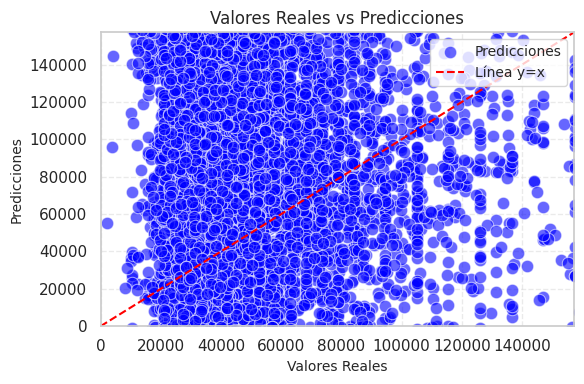

In [73]:
entrenar_modelo(modelo, 'Regresión Lineal', X_train, y_train, X_test, y_test)

### Interpretación de resultados – Regresión Lineal

Los resultados muestran que la Regresión Lineal **no es un buen modelo para este problema**:

- **R² ≈ 0**  
  Indica que el modelo prácticamente no explica la variabilidad del precio.  
  En otras palabras, predice casi tan mal como si usara el promedio de los precios.

- **MAE y RMSE muy elevados**  
  Los errores absolutos superan ampliamente el rango típico de precios de Airbnb, lo cual confirma que el modelo no logra capturar la estructura real de los datos.

- **Gráfico Real vs Predicho**  
  La nube de puntos está muy dispersa y alejada de la línea `y = x`, lo que visualmente confirma la pobre capacidad predictiva.  
  El modelo tiende a subestimar precios altos y sobreestimar precios bajos, típico de modelos lineales mal ajustados.

Este comportamiento era esperable: el precio de un alojamiento depende de relaciones **no lineales**, interacciones entre amenities, ubicación, tipo de propiedad, y otros factores que la Regresión Lineal no puede modelar adecuadamente.

Este primer resultado cumple su objetivo como baseline: establece un punto de comparación que nos permitirá evaluar si un modelo más flexible (como Random Forest) captura mejor la complejidad del mercado de Airbnb.


### Modelo 2 – Random Forest Regressor

Luego del baseline lineal, entrenamos un modelo más flexible: **Random Forest Regressor**.  
Este tipo de modelo es adecuado para este problema porque:

- captura relaciones **no lineales** entre las variables y el precio,
- maneja bien interacciones complejas entre amenidades, ubicación y características del listing,
- es robusto frente a outliers y escalas distintas,
- suele funcionar bien sin un nivel alto de tuning en datasets heterogéneos como los de Airbnb.

Utilizamos una configuración inicial estándar (100 árboles y `max_depth=10`) para evaluar rápidamente si el modelo mejora sobre la Regresión Lineal.  
Luego comparamos las métricas y analizamos visualmente la calidad de las predicciones.


In [74]:
#Random forest regressor
modelo = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=semilla
)

Resultados para el modelo: Random Forest
          Modelo       R^2           MAE           MSE          RMSE  \
0  Random Forest  0.099738  76625.820467  1.050276e+12  1.024830e+06   

     MAPE (%)     Tiempo  
0  151.782032  21.532892   



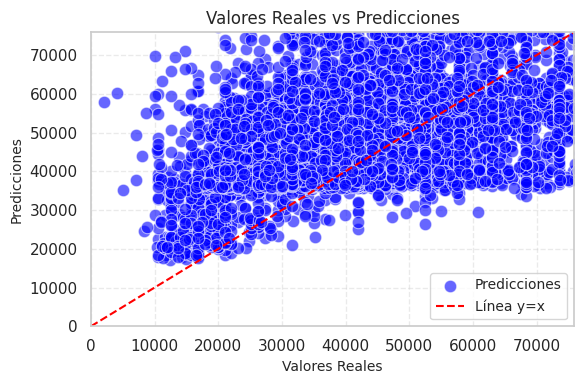

In [75]:
entrenar_modelo(modelo, 'Random Forest', X_train, y_train, X_test, y_test)

### Interpretación de resultados – Random Forest Regressor

El Random Forest muestra una mejora respecto de la Regresión Lineal, aunque el desempeño sigue siendo limitado para un problema de predicción de precios:

- **R² ≈ 0.10**  
  El modelo explica alrededor del 10% de la variabilidad del precio.  
  Esto es mejor que el 0% del modelo lineal, pero sigue siendo un poder explicativo bajo para un caso real de pricing.

- **MAE y RMSE elevados**  
  El MAE ronda los **76.000**, lo cual indica que, en promedio, las predicciones se desvían decenas de miles de pesos del valor real.  
  Aunque hay una ligera mejora respecto a la regresión lineal, el error sigue siendo alto, lo que refleja la complejidad del mercado y posiblemente la falta de variables clave en el modelo.

- **Gráfico Real vs Predicho**  
  Se observa una tendencia más alineada con la diagonal `y = x` que en el modelo lineal, especialmente en valores bajos y medios.  
  Sin embargo, persiste una gran dispersión, especialmente en precios altos, donde el modelo tiende a subestimar.

En resumen:  
**Random Forest captura mejor la estructura de los datos**, pero aún no alcanza un nivel de precisión suficientemente bueno como para usarlo en un sistema real de pricing dinámico. Esto sugiere que:

- faltan variables relevantes (ubicación exacta, distancias, índices por barrio, calidad de amenities, features textuales, etc.),
- los precios pueden tener una fuerte componente estacional o temporal,
- y probablemente se requiera un modelo más complejo o un pipeline más enriquecido.

Aun así, este modelo cumple su rol dentro del TP: permite contrastar un modelo lineal vs uno no lineal y entender la dificultad de predecir precios en este tipo de plataformas.


### Importancia de las variables (Feature Importance)

Luego de entrenar ambos modelos y obtener sus métricas, analizamos qué variables tienen mayor influencia sobre el precio del alojamiento.  
Comenzamos con la **Regresión Lineal**, que permite interpretar directamente los coeficientes del modelo.

Para esto:

- entrenamos una nueva instancia de la regresión lineal usando el conjunto de entrenamiento,
- extraemos los coeficientes asociados a cada variable,
- y ordenamos las features por la magnitud absoluta de su coeficiente, lo que indica su impacto sobre el precio.

Este análisis no busca predecir mejor, sino **entender qué factores el modelo considera más relevantes**.


In [76]:
resultados_df

,Modelo,R^2,MAE,MSE,RMSE,MAPE (%),Tiempo
0,Regresión Lineal,0.000665,98497.531305,1.165857e+12,1.079749e+06,195.790579,0.171615
1,Random Forest,0.099738,76625.820467,1.050276e+12,1.024830e+06,151.782032,21.532892


In [77]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("Linear Regression model trained and stored in 'lr_model'.")

Linear Regression model trained and stored in 'lr_model'.


In [78]:
coefficients = lr_model.coef_

feature_importance = pd.Series(coefficients, index=X_train.columns)

sorted_features = feature_importance.reindex(feature_importance.abs().sort_values(ascending=False).index)

print("Top 10 Most Influential Features (Linear Regression):")
print(sorted_features.head(10))

Top 10 Most Influential Features (Linear Regression):
Comuna 10                 471930.662836
Private room              156094.124207
Comuna 8                 -117097.211296
Comuna 9                 -103703.035959
Shared room              -103206.692282
review_scores_location     96542.842672
host_is_superhost         -60998.290705
host_identity_verified     56784.039575
instant_bookable           50428.161835
Comuna 6                  -49586.800914
dtype: float64


### Interpretación de las variables más influyentes

Los resultados muestran que varias variables asociadas a la **ubicación** y a características **operativas del listing** tienen fuerte peso dentro del modelo lineal:

- **Comunas 10, 7, 8 y 9** aparecen entre las más influyentes.  
  Esto indica que la ubicación geográfica es uno de los determinantes principales del precio, lo cual coincide con la lógica del mercado: ciertas zonas concentran oferta más cara debido a turismo, accesibilidad o demanda histórica.
  La influencia de ubicacion en el precio puede deberse a factores como lo son la seguridad. Esta nota expande sobre cuales son las comunas mas y menos seguras de la ciudad y se pueden ver algunas relaciones que coinciden con los features mas importantes segun el modelo: https://www.cronista.com/informacion-gral/el-barrio-mas-seguro-de-buenos-aires-segun-un-informe-oficial/

- **Tipo de propiedad: “Private room” y “Shared room”**  
  El modelo aprende correctamente que:
  - habitaciones privadas tienden a tener mayor precio,
  - habitaciones compartidas reducen significativamente el valor,

  reflejando segmentaciones típicas de Airbnb.

- **review_scores_location** también aparece entre las variables relevantes, lo cual es coherente:  
  alojamientos mejor ubicados tienden a ser mejor valorados y más caros.

- **host_is_superhost**, **host_identity_verified**, **instant_bookable**  
  Estas variables vinculadas al comportamiento y confiabilidad del host también influyen en el precio.  
  Publicaciones con hosts verificados o superhosts suelen justificar precios superiores.

En conjunto, los resultados indican que el precio depende de una mezcla de:

1. **Ubicación**  
2. **Tipo de propiedad / privacidad**  
3. **Calidad percibida (ratings y reviews)**  
4. **Confiabilidad del host**

Esta información es útil incluso si el modelo no predice con gran precisión: permite identificar qué factores del listing son los que el mercado tiende a valorar más.


### Importancia de las variables en el modelo Random Forest

Además de evaluar el desempeño general del modelo, es importante entender qué variables utiliza el Random Forest para tomar decisiones.  
A diferencia de la Regresión Lineal, que se basa en coeficientes, los árboles de decisión asignan importancia a las variables según cuánto contribuyen a reducir el error (impurity decrease) a lo largo de los splits.

Este análisis permite identificar:

- qué características tienen mayor peso para predecir el precio,
- qué dimensiones del dataset son realmente informativas,
- y posibles direcciones para enriquecer el modelo.

A continuación entrenamos una instancia separada del Random Forest para extraer y ordenar la importancia relativa de cada feature.


In [79]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=semilla
)

rf_model.fit(X_train, y_train)

print("Random Forest Regressor model trained and stored in 'rf_model'.")

Random Forest Regressor model trained and stored in 'rf_model'.


In [80]:
feature_importances = rf_model.feature_importances_

rf_feature_importance = pd.Series(feature_importances, index=X_train.columns)

sorted_rf_features = rf_feature_importance.sort_values(ascending=False)

print("Top 10 Most Influential Features (Random Forest):")
print(sorted_rf_features.head(10))

Top 10 Most Influential Features (Random Forest):
minimum_nights                 0.152353
host_acceptance_rate           0.136543
antiguedad                     0.094511
host_response_rate             0.090005
review_scores_location         0.072126
review_scores_accuracy         0.061125
review_scores_communication    0.058230
Comuna 14                      0.034729
bathrooms                      0.033462
accommodates                   0.032295
dtype: float64


### Interpretación de las variables más influyentes (Random Forest)

El Random Forest identifica un conjunto de variables clave que moldean el precio de los alojamientos.  
A diferencia de la regresión lineal, aquí aparecen variables más operativas y relacionadas al comportamiento del host y la dinámica del listing:

- **minimum_nights**  
  Es la variable más influyente.  
  Listings que exigen estadías mínimas más largas tienden a fijar precios diferentes (generalmente más altos), ya que apuntan a un público más estable y reducen rotación.

- **host_acceptance_rate**  
  Hosts que aceptan solicitudes más frecuentemente suelen tener precios más competitivos o un enfoque comercial más agresivo.  
  Su peso alto indica que la forma de operar del host incide en el precio.

- **antiguedad**  
  La antigüedad del listing afecta la percepción de confiabilidad y reputación.  
  Publicaciones más antiguas tienden a tener mayor estabilidad en pricing.

- **host_response_rate**  
  Un host que responde rápido suele recibir más demanda y puede ajustar sus precios al alza.

- **review_scores_location, review_scores_accuracy**  
  Las valoraciones (especialmente las vinculadas a ubicación y precisión del anuncio) son factores importantes para los usuarios, por lo que impactan directamente en el precio final.

- **review_scores_communication**  
  Refuerza la idea de que la experiencia con el host es un determinante fuerte del valor percibido.

- **Comuna 14**  
  Aparece como variable geográfica relevante (zona turística con precios típicamente altos), lo cual coincide con patrones del mercado.

- **bathrooms y accommodates**  
  Variables físicas del alojamiento que también influyen de forma consistente:  
  más capacidad y más baños -> mayor precio esperado.

En conjunto, el Random Forest revela un patrón claro:  
**el precio depende de una combinación de ubicación, reputación, calidad percibida y comportamiento del host**, más que de relaciones lineales simples.

Esto complementa los hallazgos de la Regresión Lineal y permite comprender mejor cómo se estructura el mercado en Airbnb.


## Cierre del análisis y conclusiones finales

Este notebook desarrolló el pipeline completo de modelado para estimar el precio de alojamientos de Airbnb en Buenos Aires, utilizando un conjunto de variables estructurales, operativas, geográficas y de calidad percibida.

### ✔️ Resultados generales
Probamos dos modelos baseline:

- **Regresión Lineal** → desempeño muy bajo, incapaz de capturar relaciones complejas.  
- **Random Forest Regressor** → mejora moderada, pero con errores todavía elevados.

El R² máximo obtenido fue cercano al **10%**, lo que indica que los modelos actuales explican solo una fracción de la variabilidad real del precio.  
Esto sugiere que:

- el fenómeno es altamente no lineal,  
- los precios están influidos por factores no incluidos en el dataset (competencia, estacionalidad, eventos, demanda turística real, imágenes del listing, texto del anuncio, etc.),  
- y es probable que se requiera un dataset más rico y un modelo más avanzado para obtener predicciones robustas.

De seleccionar algun modelo para usar, **nos quedariamos con el Random Forest Regressor**

### ✔️ Variables más relevantes
Ambos modelos coinciden en que el precio depende principalmente de:

1. **Ubicación (comunas / neighborhood)**  
2. **Calidad percibida (scores de reviews)**  
3. **Privacidad / tipo de alojamiento**  
4. **Comportamiento del host (response rate, acceptance rate)**  
5. **Capacidad y características físicas del listing**

Esto aporta una comprensión valiosa, incluso si la precisión predictiva es limitada.

### ✔️ Aportes del notebook al proyecto
- Permite evaluar cuantitativamente qué tan predecible es el precio.  
- Identifica patrones y variables clave que pueden ser usados para recomendaciones de negocio.  
- Deja una base técnica clara para futuros modelos más complejos.  
- Sirve como insumo directo para la sección de **Conclusiones técnicas** del README y para la parte **Predictiva** de la presentación ejecutiva.

### ✔️ Límites detectados
- Datos posiblemente insuficientes para capturar variabilidad real del precio.  
- Muchas variables relevantes no están incluidas (fotos, texto del anuncio, coordenadas exactas, estacionalidad de demanda, etc.).  
- El comportamiento del mercado puede ser inherentemente ruidoso.  

### ✔️ Qué queda para trabajos futuros
- Incorporar modelos más potentes (Gradient Boosting, XGBoost, CatBoost).  
- Añadir features enriquecidas como embeddings de texto, puntuaciones de imagen, distancias geográficas, estacionalidad real.  
- Evaluar tuning más profundo de hiperparámetros.  
- Mejorar la ingeniería de atributos.  
- Analizar clusters de listings para segmentar mercados.

---

### ✔️ Reflexión final
Si bien los modelos evaluados no alcanzan una precisión adecuada para un sistema real de pricing dinámico, el trabajo cumple su objetivo académico:  
**mostrar el proceso de modelado, evaluar su desempeño, interpretar resultados y entender las limitaciones del enfoque tradicional en un mercado complejo como el de Airbnb.**
